<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **4 - PROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as pltc
import matplotlib.colors as colors
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.preprocessingCYTO import *
from packageCYSK.processing import *
from packageCYSK.visualization import *
from packageCYSK.processing_LSF import *
from packageCYSK.processing_DCF import *
from packageCYSK.processing_CNF import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [4]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle(folder + "\\ROIs\\ROIs_HPA_TEST2.pkl")

# Import preprocessed products
data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE_TEST2.pkl")
ResultsDF = pd.read_pickle(folder + "\\ResultsDF_TEST2.pkl")

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**OPTION 1:** Select a cell from the ROIs dataframe and individually process it

**OPTION 2:** Process the whole ROIs dataset and prepare for feature extraction

Then, visualize the results by selecting the desired cell. Save ```ResultsDF``` to apply feature extraction on the next notebook.

<div class="alert alert-block alert-info">
    
 **SELECT CELL**
    
</div>

In [5]:
def dropdown_cell_eventhandler(change):
    global cell
    cell = dropdown_image.value
    lab = ROIs['Label'][dropdown_image.value]
    print('Cell ' + str(cell) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Cell:' , options = ['...'] + list(ROIs.index))
dropdown_image.observe(dropdown_cell_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Cell:', options=('...', 0), value='...')

Cell 0 (Cells) selected.


<div class="alert alert-block alert-info">
    
 **PROCESS CELL**
    
</div>

## TO DO

- curar mask da célula (? ja tenho a texture?)
- tornar processing_cell possível sem NUCL à mistura, para se eliminar este processing_cell_hpa

In [7]:
def processing_cell_hpa(rowROI,data,LSFparams):
    """
    Process a specific cell given its ROI.
       - ```rowROI```: dataframe with specific ROI corresponding to a cell
       - ```data```: data dict with the following keys:
                           - CYTO and CYTO_PRE
                           - NUCL and NUCL_PRE
       - ```LSFparams```: ALR threshold 
    
    """
    from tifffile import imread,imwrite
    global img_id,x_,y_
    
    # Useful variables:
    img_id  = rowROI['Index']
    name    = rowROI['Name']
    label   = rowROI['Label']
    mask    = retrieve_mask(rowROI['ROImask'],rowROI['Image Size']) # 1040 x 1388
    
    # Isolate deconvoluted cytoskeleton and nuclei within mask and normalize intensities
    cdeconv = data['CYTO']['Image'][img_id]
    #ndeconv = data['NUCL']['Image'][img_id]

    cyto        = mask * cdeconv
    cyto_norm   = (cyto-np.min(cyto))/(np.max(cyto)-np.min(cyto)) #cyto_norm   = mask * (cdeconv / np.max(cdeconv)) / np.max(cyto) #aux_f
    #ndeconv         = mask * ndeconv
    #ndeconv_norm   = (ndeconv-np.min(ndeconv))/(np.max(ndeconv)-np.min(ndeconv)) #ndeconv_norm   = mask * (ndeconv / np.max(ndeconv)) / np.max(ndeconv)

    # Isolate skeleton within mask
    esqueleto       = data['CYTO_PRE']['Skeleton'][img_id] * 1
    mesqueleto      = mask * esqueleto                              # aux_
    
    # Isolate skeleton with intensities within mask
    mesqueleto_int  = mesqueleto * cdeconv
    mesqueleto_norm = mesqueleto * cyto_norm
    
    # Get x and y coordinates within mask and get patches
    x_,y_   = np.where((mask*1) != 0) # resolver aqui para fazer um retangulo de branco com pad2 para as figuras ficarem direitas?
    patch_sk   = mesqueleto[min(x_):max(x_),min(y_):max(y_)]
    patch_cy   = cyto_norm[min(x_):max(x_),min(y_):max(y_)]
    #patch_nc   = ndeconv_norm[min(x_):max(x_),min(y_):max(y_)]
    
    # Get cell's centroid
    #centroid_id,centroid = ROI_centroid(data,img_id,[x_,y_])
    
    
    # NUCLEUS
#     aux_n = np.zeros_like(ndeconv)
#     rownuc = data['NUCL_PRE'].loc[centroid_id]

#     #a = list(zip(rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]))
#     aux_n[rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]] = 1

#     aux_n_ = aux_n * ndeconv_norm

#     try:
#         contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'] 
#         cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
#     except:
#         contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'][0]
#         cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
    
    
    ### DECONVOLUTED CELL FEATURES (DCFs)
#     # CYTO
#     feats_all                    = processingDCF(cyto_norm,(cyto_norm != 0)*1, mesqueleto_norm,features,data['CYTO'].loc[img_id]['Resolution'],data['CYTO'].loc[img_id]['Path'])
#     feats_labels_, feats_values_ = feats_all.print_features(print_values = False)
#     feats_labels_, feats_values_ = remove_not1D(feats_labels_,feats_values_)
#     feats_labels_                = ['DCF:' + ftf for ftf in feats_labels_]
    
#     # NUCL
#     feats_all_n                      = processingDCF(ndeconv_norm,(ndeconv_norm != 0)*1,'None',features,data['NUCL'].loc[img_id]['Resolution'],data['NUCL'].loc[img_id]['Path'])
#     feats_labels_n_, feats_values_n_ = feats_all_n.print_features(print_values = False)
#     feats_labels_n_, feats_values_n_ = remove_not1D(feats_labels_n_,feats_values_n_)
#     feats_labels_n_                  = ['DNF:' + ftn for ftn in feats_labels_n_]
    
    
    ### LINE SEGMENT FEATURES (LSFs)
    #lines, median_points, cytocenter, LSFs = line_segment_features(features,mesqueleto,img_id,mask,patch,(x_,y_),centroid,False)
    lines = skeleton_to_lines(mesqueleto,res_thr = LSFparams['res_thr'])

    ### CYTOSKELETON NETWORK FEATURES (CNFs)
    global int_ske, graph, graph_res, shollhist, cncd, pxlcount
    #graph,CNFs,shollhist = cyto_graph_features(mesqueleto_norm,features,[x_,y_],[aux_n_,centroid,cr],mask,False) #int_ske         = (mesqueleto * aux_f) / np.max(aux_f) 
    #graph       = Skeleton(skeleton_image=().astype(float)) 
    
    ### EXPORT TO SOAX
    imwrite(os.path.join(os.getcwd(), 'tosoax.tiff'), (patch_sk * patch_cy * np.max(patch_cy)* 255).astype(np.bool),photometric='minisblack')
    
    
    # Add to DataFrame
    global ResultsDF,new
    if 'ResultsDF' not in globals():
        ResultsDF = pd.DataFrame(columns = ['Path',
                                            'Name',
                                            'Img Index', 
                                            'Label',
                                            'Image Size',
                                            'Resolution', 
                                            'Mask', 
                                            'Skeleton', 
                                            'Patch:Deconvoluted Cyto', 
                                            'Patch:Skeleton Max', 
                                            'Offset', 
                                            'Lines'])

    new       = pd.Series([data['CYTO']['Path'][img_id], 
                          name,
                          img_id,
                          label,
                          rowROI['Image Size'],
                          data['CYTO']['Resolution'][img_id],
                          rowROI['ROImask'], 
                          np.where((mesqueleto*1) != 0),
                          patch_cy, 
                          
                          mesqueleto, 
                          [x_,y_],
                          
                          lines], index=ResultsDF.columns)


    ResultsDF = pd.concat([ResultsDF,new.to_frame().T],axis=0,ignore_index=True)
         
    return ResultsDF

ResultsDF = processing_cell_hpa(rowROI           = ROIs.loc[cell],
                                data             = data,
                                LSFparams        = {'res_thr': 4})

ResultsDF

C:\Users\diogo\AppData\Local\Temp\ipykernel_20752\3110505236.py:88: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  imwrite(os.path.join(os.getcwd(), 'tosoax.tiff'), (patch_sk * patch_cy * np.max(patch_cy)* 255).astype(np.bool),photometric='minisblack')


,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Skeleton,Patch:Deconvoluted Cyto,Patch:Skeleton Max,Offset,Lines
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."
1,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."
2,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."
3,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."


<div class="alert alert-block alert-info">
    
 **PROCESSING DATAFRAME**
    
</div>

In [5]:
ResultsDF = df_processing_cell(data   = data,
                               ROIsDF = ROIs,
                               params = {'res_thr': 4 })

>>> Progress: 0.0% 0
>>> Progress: 50.0% 1


<div class="alert alert-block alert-info">
    
 **PLOT PROCESSED CELLS**
    
</div>

In [5]:
fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[cell],
                            data       = data,
                            save       = False)    

AttributeError: 'tuple' object has no attribute 'values'

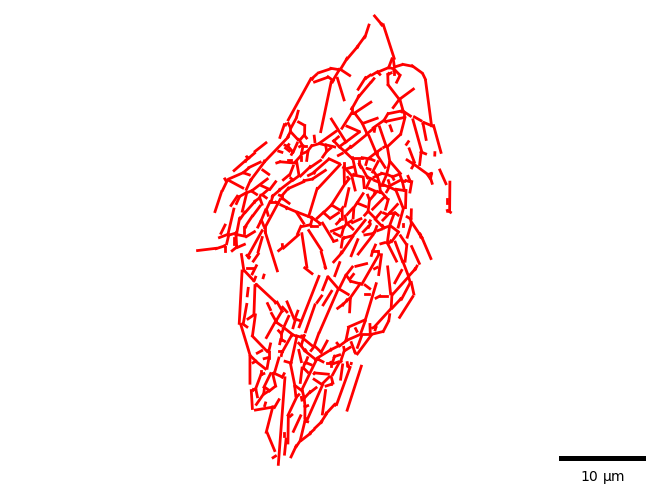

In [5]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_lines = line_plotter(ResultsRow = ResultsDF.loc[0],
                                 data=data,
                                 feat=None,
                                 cmap=cm,
                                 normalize_bounds=1,
                                 colorbar_label=None,
                                 overlay=True,
                                 save=False)

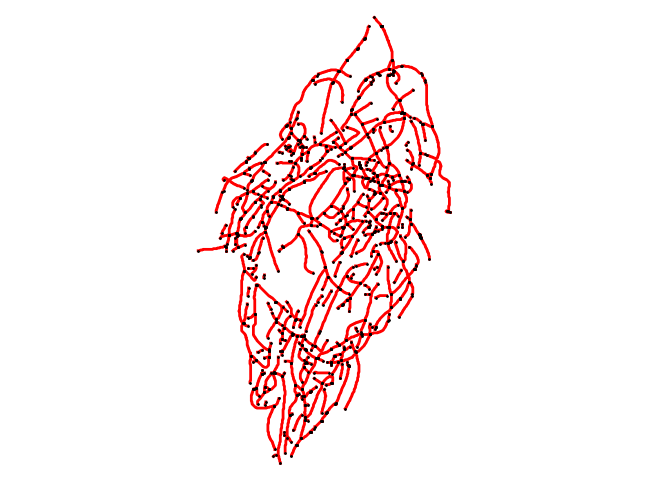

In [6]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[0],
                          data             = data,
                          feat             = None,
                          cmap             = cm,
                          normalize_bounds = 'default',
                          colorbar_label   = None,
                          nodes            = True,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = False,
                          save             = False)

In [6]:
filament_dataframes,junctionsdf = read_soax_txt('snakes.txt')

Filament DataFrames:
Filament 1:
Empty DataFrame
Columns: [s, p, x, y, z, fg_int, bg_int]
Index: [] 

Filament 2:
    s   p        x        y  z    fg_int    bg_int
0   0   0  116.330  396.287  0  39014.70      0.00
1   0   1  117.328  396.350  0  36672.50   1515.12
2   0   2  118.317  396.204  0  23716.60  12949.60
3   0   3  119.308  396.068  0  26184.10   1706.51
4   0   4  120.306  396.011  0  26699.00      0.00
.. ..  ..      ...      ... ..       ...       ...
57  0  57  162.027  368.267  0   9672.54      0.00
58  0  58  162.648  367.483  0   4487.97      0.00
59  0  59  163.368  366.789  0   4610.56      0.00
60  0  60  164.159  366.178  0   9654.24   1574.06
61  0  61  164.944  365.558  0   6569.04   4180.83

[62 rows x 7 columns] 

Filament 3:
    s   p        x        y  z   fg_int     bg_int
0   1   0  155.452  380.056  0  19212.9    38.0994
1   1   1  156.453  380.023  0  19152.7   842.7800
2   1   2  157.454  380.034  0  12189.2  2418.9700
3   1   3  158.456  380.036  0  1

    s  p        x        y  z    fg_int    bg_int
0  88  0  210.997  194.059  0      0.00     0.000
1  88  1  211.713  193.319  0   6530.14     0.000
2  88  2  212.422  192.571  0   7421.73     0.000
3  88  3  213.104  191.798  0  12290.30    45.626
4  88  4  213.743  190.991  0  17422.90  3194.660
5  88  5  214.458  190.248  0  24876.70  2112.010
6  88  6  215.133  189.469  0  30038.70   150.172 

Filament 91:
    s  p        x        y  z    fg_int   bg_int
0  89  0  319.078  443.985  0      0.00     0.00
1  89  1  319.586  444.812  0   6609.29     0.00
2  89  2  320.073  445.651  0  12053.90     0.00
3  89  3  320.521  446.512  0   7344.64     0.00
4  89  4  320.958  447.378  0  14940.30     0.00
5  89  5  321.444  448.218  0   8562.98     0.00
6  89  6  321.983  449.024  0  24492.80   250.19
7  89  7  322.438  449.882  0  14859.40  7173.33 

Filament 92:
     s   p        x        y  z      fg_int  bg_int
0   90   0  258.769  652.058  0      0.0000     0.0
1   90   1  258.168  651.

In [6]:
filament_dataframes

[                                     0      1     2     3     4     5     6   \
 1                     intensity-scaling      0  None  None  None  None  None   
 2                          gaussian-std      0  None  None  None  None  None   
 3                       ridge-threshold   0.01  None  None  None  None  None   
 4                    maximum-foreground  65535  None  None  None  None  None   
 5                    minimum-foreground      0  None  None  None  None  None   
 6                                init-z   true  None  None  None  None  None   
 7                   snake-point-spacing      1  None  None  None  None  None   
 8                  minimum-snake-length      4  None  None  None  None  None   
 9                    maximum-iterations  10000  None  None  None  None  None   
 10                     change-threshold    0.1  None  None  None  None  None   
 11                         check-period    100  None  None  None  None  None   
 12                         

In [5]:
junctionsdf

,X,Y,Z
0,128.1430,393.452,0
1,155.4520,380.056,0
2,175.2290,373.841,0
3,50.3283,332.127,0
4,56.0426,348.876,0
...,...,...,...
161,94.8820,274.876,0
162,103.6280,147.802,0
163,203.6930,165.043,0
164,132.3320,207.158,0


In [7]:
ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Skeleton,Patch:Deconvoluted Cyto,Patch:Skeleton Max,Offset,Lines
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([198, 199, 200, 201, 202, 203, 204, 205, 206,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.616, 198.458), (137.121, 323.087)), ((1..."


In [15]:
ResultsDF.loc[0]

Path                       C:\Users\diogo\OneDrive - Universidade de Lisb...
Name                                                 Cells_HPA_Cells_abc.tif
Img Index                                                                HPA
Label                                                                  Cells
Image Size                                                      (2048, 2048)
Resolution                                                   (1, 0.08, 0.08)
Mask                       ([163, 164, 164, 164, 164, 164, 165, 165, 165,...
Skeleton                   ([198, 199, 200, 201, 202, 203, 204, 205, 206,...
Patch:Deconvoluted Cyto    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Patch:Skeleton Max         [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Offset                     [[163, 164, 164, 164, 164, 164, 165, 165, 165,...
Lines                      [((127.616, 198.458), (137.121, 323.087)), ((1...
Name: 0, dtype: object

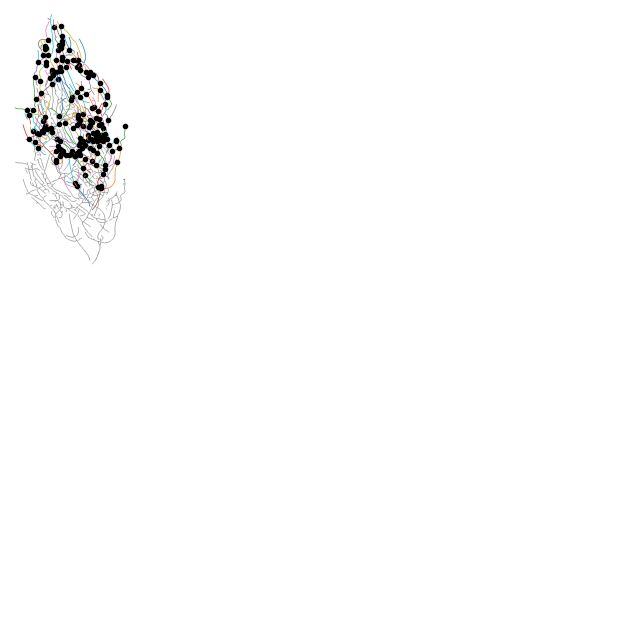

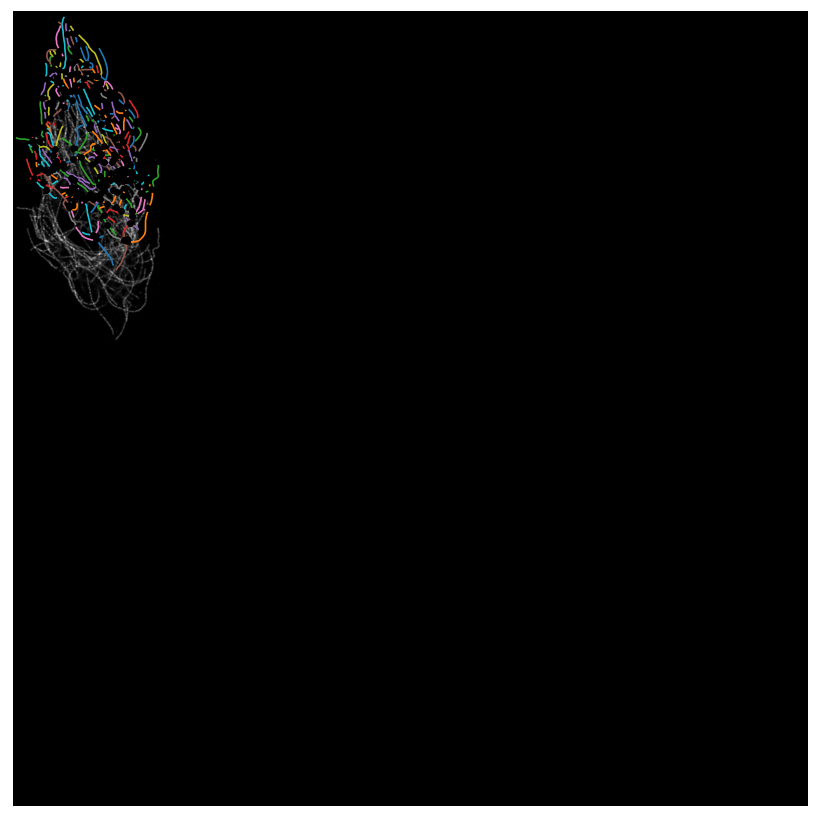

In [14]:
def plot_soax(ResultsRow,data,filaments_df,junctions_df):
    
    img       = data['CYTO']['Image'][str(ResultsRow['Img Index'])] / np.max(data['CYTO']['Image'][str(ResultsRow['Img Index'])])
    imgorig = retrieve_mask(ResultsRow['Mask'],ResultsRow['Image Size']) * img
    
    skel = retrieve_mask(ResultsRow['Skeleton'],ResultsRow['Image Size'])
    
    fig,ax = plt.subplots(figsize=(8,8))
    fig2,ax2 = plt.subplots(figsize=(8,8))
    ax.imshow(np.max(skel)-skel,cmap='gray',alpha=1,zorder=1)
    ax2.imshow(imgorig,cmap='gray')
    ax.axis('off')
    ax2.axis('off')
    ax.axis('equal')
    ax2.axis('equal')
    
    zorder = 2
    # PLOT FILAMENT
    for filament in filaments_df:
        x = []
        y = []
        x = [float(a) for a in filament['x']] 
        y = [float(b) for b in filament['y']]
            
        
        ax.plot(x,y,linewidth=0.5,zorder=zorder)
        ax2.plot(x,y,linewidth=1.2,zorder=zorder)
        zorder += 1
    
    # PLOT JUNCTION
    for index,row in junctions_df.iterrows():
        ax.plot(row[0],row[1],'ko',zorder=200,markersize=3)
        ax2.plot(row[0],row[1],'ko',zorder=300,markersize=4)
    
    plt.tight_layout(pad=0)
    #fig.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("skelsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    #fig2.savefig("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA\\figs\\fig2\\" + str("origsoax") + ".pdf",format='pdf',transparent=True,bbox_inches='tight')
    
    
    
    plt.show()
                    

#plot_soax(np.max(imagens[0]) - imagens[0][180:860,0:400],skelorig,filament_dataframes,junctionsdf)
plot_soax(ResultsRow          = ResultsDF.loc[0],
          data                = data,
          filaments_df        = filament_dataframes,
          junctions_df        = junctionsdf)

<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME FOR FEATURE EXTRACTION**
    
</div>

In [7]:
ResultsDF.to_pickle(folder + '//ResultsDF_TEST2.pkl')   

---